# Notebook 2: distribution of pool size

**This notebook's question:** in a typical game, how often does a pool of a given size N occur? And how long does each game phase last (i.e. the stretch of the game with a given number of active players)?

This is the **weight w(N)** the brief talks about: notebook 1 computed p(N) for each hand separately, but didn't know how important each N actually is. This notebook fills that gap. Notebook 3 combines p(N) with w(N) to get a single "how good is this ranking" number for the whole game.

**Important:** here we do **not** compute odds of card hands. We only compute **the flow of the points-based betting**: who loses each round and when they drop out. Cards enter the picture only in notebook 3.

In [1]:
import math
from fractions import Fraction

import matplotlib.pyplot as plt
import pandas as pd

from tayan_lab.pool_size_distribution import pool_size_distribution

INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": GRID,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})
SEQ = ["#eef6ff", "#bcdcfb", "#7bb8ef", "#2a78d6", "#1a4e94", "#0d2c57"]  # sequential blue ramp

## 1. Game state as a Markov chain

A **state** is a list of how many cards each surviving player has, e.g. `(2, 2, 3)`. Player order doesn't matter (mathematically it's the same state), so we always sort it. The pool is then N = the sum of that list.

**Transition rule:** in every round one player "loses" (gets +1 card). If that brings them to the limit (default 6, i.e. **a hand of at most 5 cards is the max**), they drop out.

**Why there are no cycles - i.e. why this is even easy to compute:** define

$$\text{points}(state) = \sum(\text{active players' cards}) + \text{limit} \times (\text{players} - \text{active})$$

Every round raises this number by **exactly 1** (either someone gets a card, or they drop out and "freeze" their points at the limit). The game never returns to the same points level, so we can process states **in waves**, from the lowest point total to the highest, without solving systems of equations - we just sum probabilities forward.

## 2. A worked example: 2 players, 1 starting card, limit 3

The smallest possible example, to see the mechanics step by step.

- **Round 1.** State (1, 1), N = 2. Someone loses, gets a card → state (1, 2). Since both players are symmetric, this is the only possible outcome, with probability 1.
- **Round 2.** State (1, 2), N = 3. One of the two players loses, each with a 1/2 chance:
  - the 1-card player loses → now has 2 cards → state (2, 2), game continues,
  - the 2-card player loses → now has 3 cards → **drops out** (limit = 3) → 1 player left → **game ends**.
- **Round 3** (only in the branch where the game continues, i.e. with probability 1/2). State (2, 2), N = 4. Whoever loses gets a 3rd card and drops out → game ends.

**Expected number of rounds at each N:** N=2 → 1 (always), N=3 → 1 (always), N=4 → 0.5 (only in half the games). Average game length: 1 + 1 + 0.5 = **2.5 rounds**. Below is the same thing from the module - it must come out identical, down to the fraction.

In [2]:
d = pool_size_distribution(players=2, starting_cards=1, elimination_limit=3)
print("rounds for each N:", d.by_pool_size)
print("expected game length:", d.expected_rounds, "=", float(d.expected_rounds))

rounds for each N: {2: Fraction(1, 1), 3: Fraction(1, 1), 4: Fraction(1, 2)}
expected game length: 5/2 = 2.5


## 3. Control values from the brief

2 starting cards, limit 6, random loser (base model).

In [3]:
for players, expected in [(3, 10.09), (6, 22.33)]:
    d = pool_size_distribution(players, starting_cards=2, elimination_limit=6)
    print(f"{players} players: {float(d.expected_rounds):.2f} rounds  (brief: {expected})")

3 players: 10.09 rounds  (brief: 10.09)
6 players: 22.33 rounds  (brief: 22.33)


## 4. The distribution w(N): how often a given pool size occurs

For a few player counts we show the share of rounds falling on each N (i.e. w(N) = rounds(N) / total rounds). This is exactly the weight notebook 3 multiplies by notebook 1's p(N).

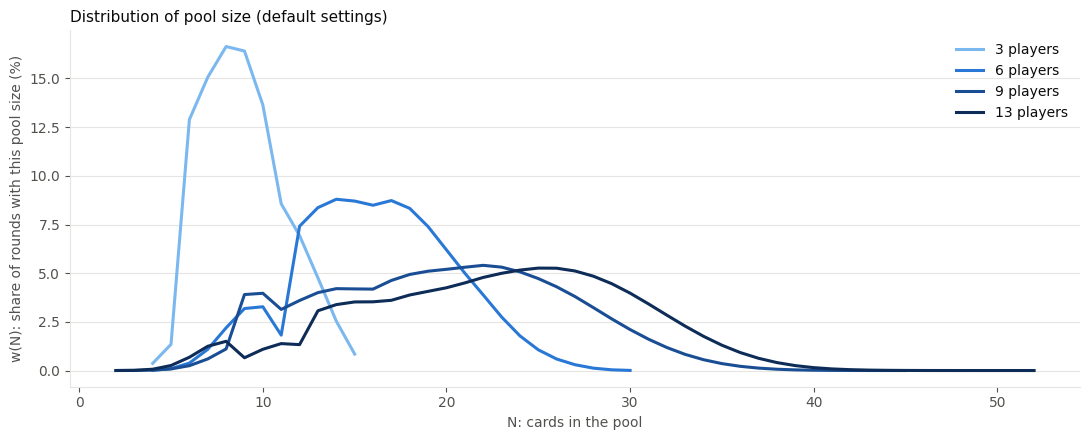

In [4]:
def default_limit(players):
    return 6 if players <= 10 else 5

def default_start(players):
    return 2 if players <= 6 else 1

fig, ax = plt.subplots(figsize=(11, 4.5))
shown = [3, 6, 9, 13]
for i, players in enumerate(shown):
    d = pool_size_distribution(players, default_start(players), default_limit(players))
    ns = sorted(d.by_pool_size)
    w = [float(d.by_pool_size[n] / d.expected_rounds) * 100 for n in ns]
    ax.plot(ns, w, color=SEQ[2 + i if 2 + i < len(SEQ) else -1], lw=2.2, label=f"{players} players")
ax.set_xlabel("N: cards in the pool")
ax.set_ylabel("w(N): share of rounds with this pool size (%)")
ax.set_title("Distribution of pool size (default settings)", loc="left", color=INK, fontsize=11)
ax.grid(axis="y", color=GRID, lw=0.8)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**How to read this:** the curve shows how long the game "dwells" at each N. With more players the pool tends to get much larger (players have time to accumulate cards before anyone drops out), but there's also a long tail along the way: after drop-outs N sometimes shrinks (fewer active players), then grows again.

## 5. Average game length for each player count (2-13)

In [5]:
rows = []
for players in range(2, 14):
    d = pool_size_distribution(players, default_start(players), default_limit(players))
    rows.append({"players": players, "start": default_start(players), "limit": default_limit(players),
                 "avg. game length (rounds)": round(float(d.expected_rounds), 2)})
df_len = pd.DataFrame(rows)
df_len.style.hide(axis="index")

players,start,limit,avg. game length (rounds)
2,2,6,5.810000
3,2,6,10.090000
4,2,6,14.210000
5,2,6,18.280000
6,2,6,22.330000
7,1,6,33.230000
8,1,6,38.260000
9,1,6,43.290000
10,1,6,48.310000
11,1,5,42.450000


## 6. Game phases: how long each phase lasts and its N distribution

A **phase** is the stretch of the game with a given number of active players. Players drop out one at a time, so **every game passes through every phase** from the starting player count down to 2. This matters for the "dead phase" criterion used later when picking the deck: by definition every phase lasts at least 1 round, so that criterion on its own won't filter anything out - we'll come back to this in notebook 4.

Chart below: a 6-player game, each phase its own color (darker = fewer active players = later in the game).

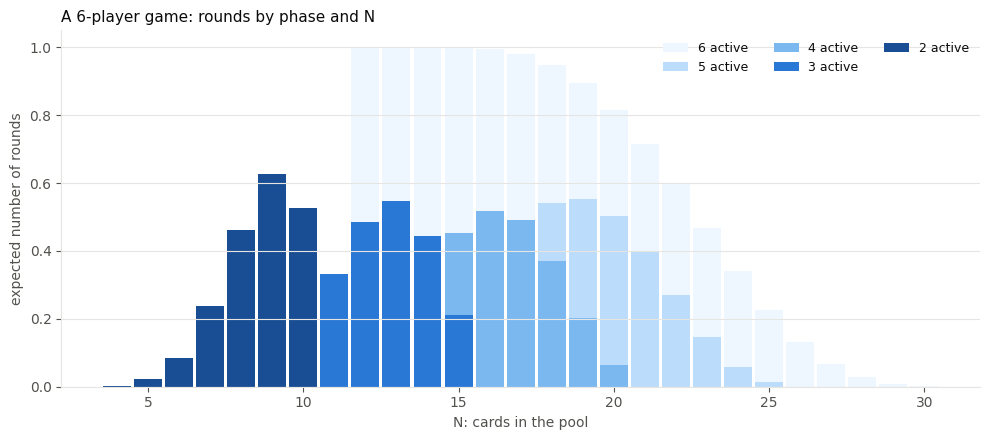

active players,avg. rounds in phase,N: min-max
6,11.210000,12-30
5,3.990000,10-25
4,2.860000,8-20
3,2.310000,6-15
2,1.960000,4-10


In [6]:
players0 = 6
d = pool_size_distribution(players0, default_start(players0), default_limit(players0))
fig, ax = plt.subplots(figsize=(10, 4.5))
phases = sorted(d.by_phase, reverse=True)  # from the largest down to the final
for i, phase in enumerate(phases):
    ns = sorted(d.by_phase[phase])
    rounds = [float(d.by_phase[phase][n]) for n in ns]
    color = SEQ[min(i, len(SEQ) - 1)]
    ax.bar(ns, rounds, color=color, width=0.9, label=f"{phase} active")
ax.set_xlabel("N: cards in the pool")
ax.set_ylabel("expected number of rounds")
ax.set_title(f"A {players0}-player game: rounds by phase and N", loc="left", color=INK, fontsize=11)
ax.grid(axis="y", color=GRID, lw=0.8)
ax.legend(frameon=False, ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

rows = []
for phase in phases:
    rounds = sum(d.by_phase[phase].values())
    ns = list(d.by_phase[phase])
    rows.append({"active players": phase, "avg. rounds in phase": round(float(rounds), 2),
                 "N: min-max": f"{min(ns)}-{max(ns)}"})
pd.DataFrame(rows).style.hide(axis="index")

## 7. Loser models (sensitivity analysis)

The brief asks us to check three models of who loses a round:

1. **uniform** - every active player has the same odds (base model),
2. **1/cards** - a player with more cards loses less often, weight = 1 / (number of cards). A simplification: a genuinely skilled player could survive on few cards for even longer in reality, but a simple model is enough for this study,
3. **fewest cards always loses** - whoever has the fewest cards loses (ties broken randomly).

We check how much the model changes average game length.

In [7]:
rows = []
for players in (3, 6, 9):
    row = {"players": players}
    for model, label in [("uniform", "uniform"), ("inverse_cards", "1/cards"), ("fewest_cards", "fewest cards")]:
        d = pool_size_distribution(players, default_start(players), default_limit(players), loser_model=model)
        row[label] = round(float(d.expected_rounds), 2)
    rows.append(row)
pd.DataFrame(rows).style.hide(axis="index")

players,uniform,1/cards,fewest cards
3,10.090000,10.450000,11.000000
6,22.330000,22.670000,23.000000
9,43.290000,43.730000,44.000000


**How to read this:** the "fewest cards always loses" model should lengthen the game the most - it keeps chasing the weaker player instead of randomly picking off the stronger one, so more rounds pass before anyone even nears the limit. The "1/cards" model sits in between.

## 8. Computation speed

For the game's implementation it matters whether the static ranking can be computed on the fly at game start, or whether a precomputed table is needed. We measure the worst case: 13 players.

In [8]:
import time

times = []
for _ in range(5):
    t0 = time.perf_counter()
    pool_size_distribution(13, default_start(13), default_limit(13))
    times.append(time.perf_counter() - t0)
print(f"13 players: {min(times)*1000:.1f} ms (best of 5 measurements)")

13 players: 128.5 ms (best of 5 measurements)


**Conclusion:** even the worst case (13 players) computes in a fraction of a second in Python on an ordinary CPU. On the game server (0.1 vCPU, but in TypeScript, usually faster than plain Python for this kind of integer arithmetic) this comfortably fits a "compute at game start" budget. This result favors computing the ranking on the fly over keeping a precomputed table.

## 9. Conclusions

**What is established (exactly, as fractions):**

- The N distribution and phase length for every player count (2-13) and each of the 3 loser models is computed exactly, via a Markov chain, with no simulation.
- The brief's control values (3 players -> 10.09 rounds, 6 players -> 22.33 rounds) match to two decimal places.
- The hand-worked example (2 players, 1 starting card, limit 3) matches down to the fraction: 1, 1, 0.5 rounds for N = 2, 3, 4.
- Every game phase (a given number of active players) occurs in every game and lasts on average >= 1 round - by definition, since players drop out one at a time. **This means a "dead phase" criterion phrased only as "a phase averaging >= 1 round" won't filter out any phase on its own.** To be decided later (notebook 4): keep the criterion as-is, or tighten it (e.g. weight by share of the game's total rounds).
- The computations are fast (a fraction of a second even for 13 players), so the static ranking can be computed on the fly at game start, without keeping a table.

**Uncertainty:** every number is an exact value from a formula (a Markov chain on fractions), confirmed by Monte Carlo only as a code-correctness check, not as a source of uncertainty in the result.

**What we still don't do:** we don't yet combine this with the hand odds from notebook 1. That's notebook 3.